In [1]:
import numpy as np
import numba as nb
import scipy as sp
from scipy import integrate, optimize

import matplotlib.pyplot as plt
import matplotlib as mpl

from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append('..')

%matplotlib inline

In [2]:
ETEST_LABEL = r"$E_{{test}}$"
PHI_LABEL = r"$\phi = n / d$"
PSI_LABEL = r"$\psi = p / d$"

def get_colors_range(n_values, cmap_name="viridis", use_bounds=False):
    n_colors = n_values 
    if use_bounds:
        n_colors += 2
    cmap = plt.get_cmap(cmap_name, n_colors)
    colors = [cmap(i) for i in range(n_colors)]
    return colors

In [ ]:
from theory.theory import GF_test_error, GF_test_error_inf_time


def reparam_new_to_old(phi, psi):
    """
    phi: n / d - should be in (0, infty)
    psi: p / d - should be in (0, 1)

    Reminder that in original parameterization, psi = d / n, alpha = p / n
    (i.e. psi in (0, infty), alpha in (0, psi))
    """
    old_psi = 1 / phi
    old_alpha = psi / phi
    return old_psi, old_alpha


def GF_test_error_reparam_proxy(phi, psi, t, betadiff2=2, beta2=1, mu2=0.):
    old_psi, old_alpha = reparam_new_to_old(phi, psi)
    return GF_test_error(old_alpha, t, psi=old_psi, betadiff2=betadiff2, beta2=beta2, mu2=mu2)


def GF_test_error_inf_time_reparam_proxy(phi, psi, betadiff2=2, beta2=1, mu2=0.):
    old_psi, old_alpha = reparam_new_to_old(phi, psi)
    return GF_test_error_inf_time(old_alpha, psi=old_psi, betadiff2=betadiff2, beta2=beta2, mu2=mu2)

# TODO: idk if I want to keep it
def GF_test_error_inf_time_reparam(phi, psi, betadiff2=2, beta2=1, mu2=0.):
    psi_minus_phi = psi - phi
    # 1. below is placeholder value
    psi_minus_phi_safe = np.where(psi_minus_phi == 0., 1., psi_minus_phi) 
    res = betadiff2 * np.maximum(psi_minus_phi, 0.) + \
         ((1 - psi) * beta2 + mu2) * np.maximum(psi, phi) / np.abs(psi_minus_phi_safe)
    res = np.where(psi_minus_phi == 0., np.inf, res)
    res = res / 2.
    return res

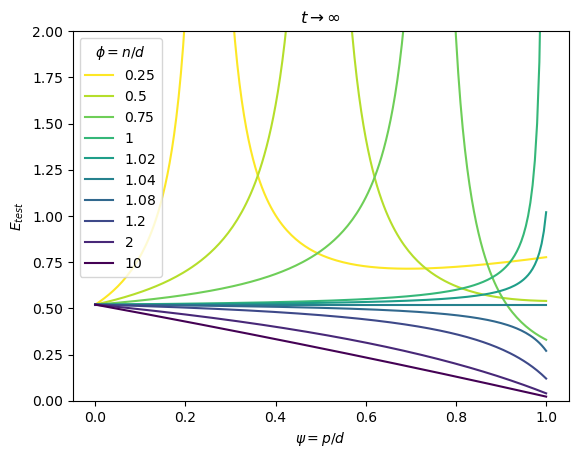

In [4]:
phi_values = [0.25, 0.5, 0.75, 1, 1.02, 1.04, 1.08, 1.2, 2, 10]
phi_colors = get_colors_range(len(phi_values), cmap_name="viridis_r")
psi = np.linspace(0, 1, 201)
mu2 = 0.04

fig, ax = plt.subplots()
for i, phi in enumerate(phi_values):
    ax.plot(psi, GF_test_error_inf_time_reparam_proxy(phi, psi, mu2=mu2), c=phi_colors[i], label=fr'${phi}$')
ax.set_ylabel(ETEST_LABEL)
ax.set_xlabel(PSI_LABEL)
ax.set_ylim(0, 2)
ax.legend(title=PHI_LABEL)
ax.set_title(r'$t \to \infty$')
plt.show()

/Users/remizova/SMILS/sgf_dyn/notebooks/../theory/theory.py:189: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  return quad(gf_test_int1_c, aminus, aplus, args=(t, aminus, aplus))[0]
/Users/remizova/SMILS/sgf_dyn/notebooks/../theory/theory.py:189: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(gf_test_int1_c, aminus, aplus, args=(t, aminus, aplus))[0]


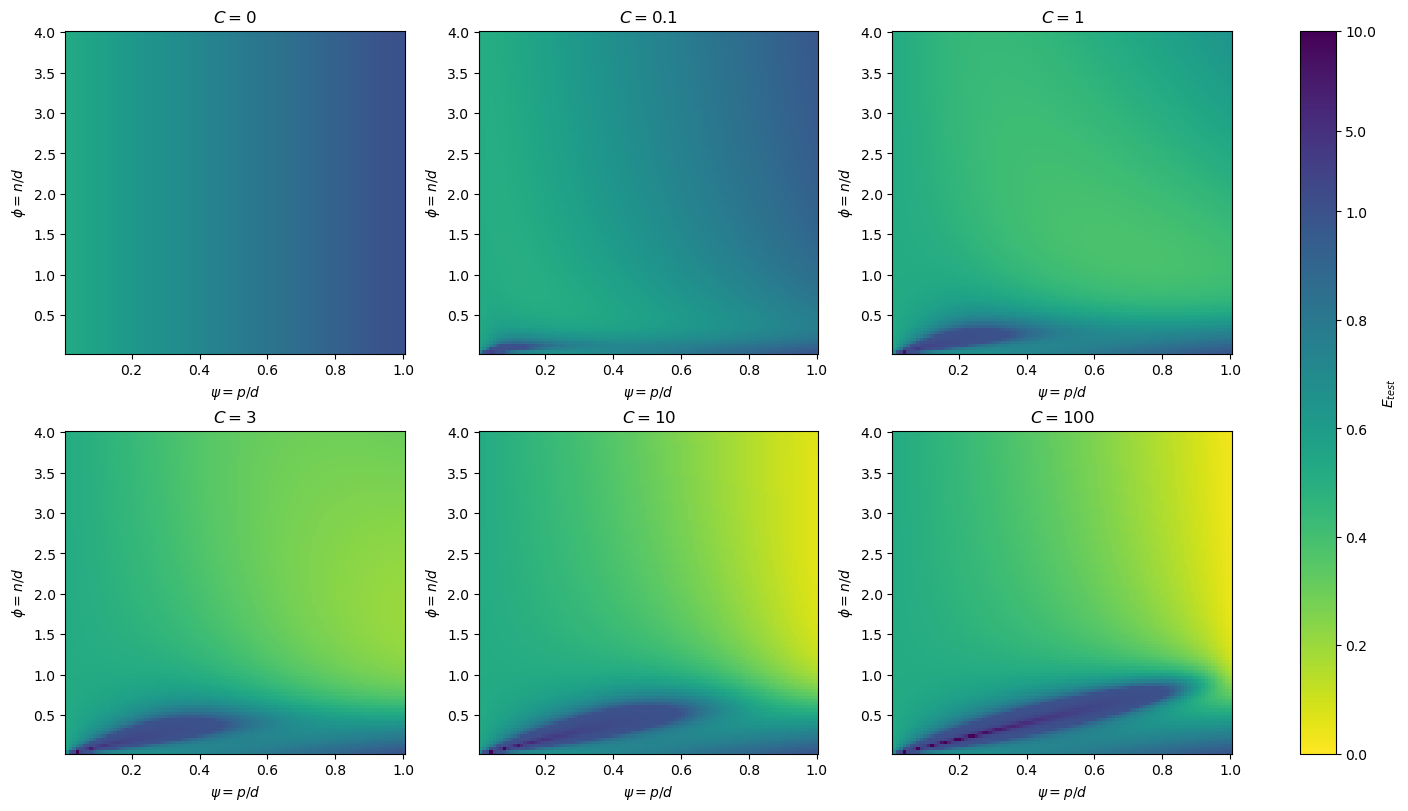

In [5]:
from matplotlib.colors import Normalize

class SplitNorm(Normalize):
    def __init__(self, vmin, vsplit, vmax, split_frac=0.75):
        self.vsplit = vsplit
        self.split_frac = split_frac
        super().__init__(vmin, vmax)

    def __call__(self, value, clip=None):
        v = np.ma.asarray(value).astype(float)
        lo = self.split_frac * (v - self.vmin) / (self.vsplit - self.vmin)
        hi = self.split_frac + (1 - self.split_frac) * (v - self.vsplit) / (self.vmax - self.vsplit)
        result = np.where(v <= self.vsplit, lo, hi)
        return np.ma.array(np.clip(result, 0, 1), mask=v.mask)

    def inverse(self, value):
        # validate: np.allclose(value, norm.inverse(norm(value)))
        v = np.ma.asarray(value).astype(float)
        lo = self.vmin + v / self.split_frac * (self.vsplit - self.vmin)
        hi = self.vsplit + (v - self.split_frac) / (1 - self.split_frac) * (self.vmax - self.vsplit)
        result = np.where(v <= self.split_frac, lo, hi)
        return np.ma.array(result, mask=v.mask)


phi = np.linspace(0, 4, 101)[1:][:, np.newaxis]
# it is good to avoid exact equality between phi and psi; otherwise it diverges with time
# this can be done by choosing spacing properly
psi = np.linspace(0, 1, 100)[1:][np.newaxis, :]  
mu2 = 0.04

C_values = [0, 0.1, 1, 3, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout='constrained')
norm = SplitNorm(vmin=0, vsplit=1, vmax=10, split_frac=0.75)

ticks_lo = np.linspace(0, 1, 6)  # ticks across 75% of bar
ticks_hi = np.array([5, 10])  # ticks across 25% of bar
ticks = np.concatenate([ticks_lo, ticks_hi])

for ax, C in zip(axes.ravel(), C_values):
    t = C / (phi * psi)

    # draw mesh
    etest = GF_test_error_reparam_proxy(phi, psi, t, betadiff2=2, beta2=1, mu2=mu2)

    mesh = ax.pcolormesh(psi.ravel(), phi.ravel(), etest, cmap='viridis_r', norm=norm)
    ax.set_xlabel(PSI_LABEL)
    ax.set_ylabel(PHI_LABEL)
    ax.set_title(fr'$C={C}$')

fig.colorbar(mesh, ax=axes.ravel().tolist(), label=ETEST_LABEL, ticks=ticks)
# plt.tight_layout()
plt.show()

In [6]:
C_values = np.logspace(-3, 2, 101)
phi = np.linspace(0, 20, 201)[1:]
phi_view = phi[:, np.newaxis]
psi = np.linspace(0, 1, 200)[1:]
psi_view = psi[np.newaxis, :]
mu2 = 0.04

etest_min = np.empty_like(C_values)
phi_min = np.empty_like(C_values)
psi_min = np.empty_like(C_values)
for i_C, C in tqdm(enumerate(C_values)):
    t = C / (phi_view * psi_view)
    etest = GF_test_error_reparam_proxy(phi_view, psi_view, t, betadiff2=2, beta2=1, mu2=mu2)
    ind = np.unravel_index(np.argmin(etest, axis=None), etest.shape)
    etest_min[i_C] = etest[ind]
    phi_min[i_C] = phi[ind[0]]
    psi_min[i_C] = psi[ind[1]]
    


0it [00:00, ?it/s]

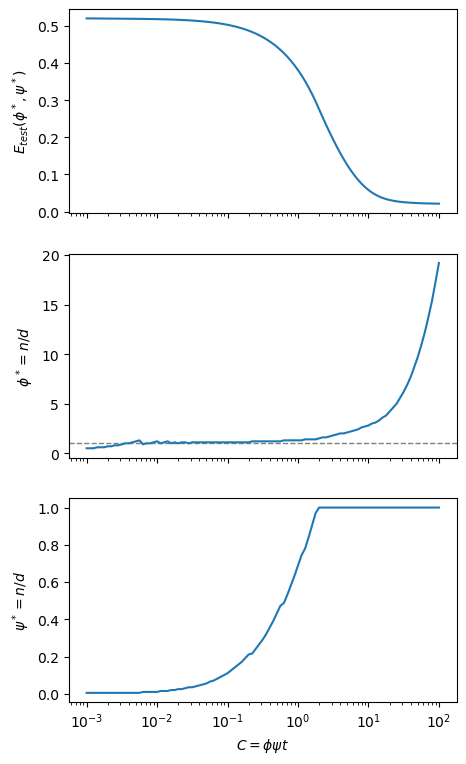

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(5, 9), sharex=True)
ax[0].plot(C_values, etest_min)
ax[0].set_xscale('log')
ax[0].set_ylabel(r"$E_{{test}}(\phi^*, \psi^*)$")
ax[1].axhline(y=1, color='gray', linestyle='--', lw=1)
ax[1].plot(C_values, phi_min)
ax[1].set_ylabel(r"$\phi^* = n / d$")
ax[2].plot(C_values, psi_min)
ax[2].set_ylabel(r"$\psi^* = n / d$")
ax[2].set_xlabel(r'$C = \phi \psi t$')
plt.show()